# Layer 2 — Unsupervised Anomaly Detection
## Isolation Forest + LSTM Autoencoder

**Purpose:** Detect fraud patterns that Layer 1 (XGBoost) cannot see — novel, previously unseen fraud methods that have no historical label.  
**Thesis Chapter:** Chapter 5 — Model Development & Evaluation (Layer 2)

### Why This Layer Exists
XGBoost is a supervised model — it learns from labelled examples of past fraud.
But fraudsters constantly invent new methods that have never been seen before.
Layer 2 uses **unsupervised learning** — it does not need fraud labels.
Instead it learns what **normal** looks like, and flags anything that deviates significantly.

Two complementary approaches are used:
- **Isolation Forest**: Detects point anomalies — individual transactions that are statistically unusual
- **LSTM Autoencoder**: Detects sequential anomalies — unusual patterns in a user's transaction behaviour over time

Run cells top to bottom. Do not skip sections.

---
## Section 1 — Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, RepeatVector,
    TimeDistributed, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import json
import pickle
import os

# Plot styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs('models', exist_ok=True)

print(f'TensorFlow version : {tf.__version__}')
print('All imports loaded successfully.')

TensorFlow version : 2.21.0
All imports loaded successfully.


---
## Section 2 — Load Data

In [2]:
train = pd.read_csv('data/transactions_train.csv', parse_dates=['timestamp'])
val   = pd.read_csv('data/transactions_val.csv',   parse_dates=['timestamp'])
test  = pd.read_csv('data/transactions_test.csv',  parse_dates=['timestamp'])

print(f'Train : {len(train):,} rows | Fraud: {train.is_fraud.sum():,}')
print(f'Val   : {len(val):,} rows  | Fraud: {val.is_fraud.sum():,}')
print(f'Test  : {len(test):,} rows  | Fraud: {test.is_fraud.sum():,}')

Train : 140,000 rows | Fraud: 676
Val   : 30,000 rows  | Fraud: 139
Test  : 30,000 rows  | Fraud: 171


---
## Section 3 — Feature Preparation
Unsupervised models require scaled numeric features only.
We use the same feature set as Layer 1 for consistency.

In [3]:
CAT_COLS = ['channel', 'sender_bank', 'beneficiary_bank', 'state']

FEATURE_COLS = [
    'amount_ngn', 'is_interbank', 'is_agent_transaction', 'is_new_beneficiary',
    'hour_of_day', 'day_of_week', 'is_weekend', 'is_public_holiday', 'is_off_hours',
    'sim_age_days', 'sim_swap_flag', 'device_fingerprint_changed',
    'geo_displacement_flag', 'nin_bvn_mismatch',
    'velocity_1h', 'velocity_6h', 'velocity_24h', 'cumulative_send_24h_ngn',
    'channel_enc', 'sender_bank_enc', 'beneficiary_bank_enc', 'state_enc',
]

def encode_cats(df_train, df_val, df_test, cat_cols):
    encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        df_train[f'{col}_enc'] = le.fit_transform(df_train[col].astype(str))
        df_val[f'{col}_enc']   = le.transform(df_val[col].astype(str))
        df_test[f'{col}_enc']  = le.transform(df_test[col].astype(str))
        encoders[col] = le
    return df_train, df_val, df_test, encoders

train, val, test, encoders = encode_cats(train, val, test, CAT_COLS)

bool_cols = [
    'is_interbank','is_agent_transaction','is_new_beneficiary',
    'is_weekend','is_public_holiday','is_off_hours',
    'sim_swap_flag','device_fingerprint_changed',
    'geo_displacement_flag','nin_bvn_mismatch'
]
for df_ in [train, val, test]:
    for col in bool_cols:
        df_[col] = df_[col].astype(int)

X_train = train[FEATURE_COLS].fillna(0)
X_val   = val[FEATURE_COLS].fillna(0)
X_test  = test[FEATURE_COLS].fillna(0)
y_test  = test['is_fraud'].values
y_train = train['is_fraud'].values
y_val   = val['is_fraud'].values

# Scale features — critical for both Isolation Forest and LSTM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Training data for unsupervised: legitimate transactions only
# The model learns what NORMAL looks like
legit_mask     = y_train == 0
X_train_legit  = X_train_scaled[legit_mask]

print(f'Feature matrix     : {X_train_scaled.shape}')
print(f'Legit-only train   : {X_train_legit.shape}')
print(f'Fraud rate in test : {y_test.mean()*100:.2f}%')

Feature matrix     : (140000, 22)
Legit-only train   : (139324, 22)
Fraud rate in test : 0.57%


---
## Section 4 — Isolation Forest

### How It Works (Plain Language)
Isolation Forest works by randomly cutting the data into smaller and smaller pieces.
Normal transactions take many cuts to isolate because they cluster together.
Anomalies (fraud) are isolated quickly because they sit far from the cluster.
The fewer cuts needed to isolate a point, the higher its anomaly score.

In [4]:
print('Training Isolation Forest...')

iso_forest = IsolationForest(
    n_estimators=300,
    max_samples='auto',
    contamination=0.005,   # ~0.5% expected fraud rate
    random_state=SEED,
    n_jobs=-1
)

# Train on legitimate transactions only
iso_forest.fit(X_train_legit)

# Score test set
# decision_function returns negative scores — more negative = more anomalous
iso_scores_raw = iso_forest.decision_function(X_test_scaled)

# Convert to anomaly score between 0 and 1 (higher = more anomalous)
iso_scores = 1 - (iso_scores_raw - iso_scores_raw.min()) / \
             (iso_scores_raw.max() - iso_scores_raw.min())

# Binary prediction using contamination threshold
iso_preds = (iso_forest.predict(X_test_scaled) == -1).astype(int)

# Metrics
iso_precision = precision_score(y_test, iso_preds, zero_division=0)
iso_recall    = recall_score(y_test, iso_preds, zero_division=0)
iso_f1        = f1_score(y_test, iso_preds, zero_division=0)
iso_roc_auc   = roc_auc_score(y_test, iso_scores)
iso_pr_auc    = average_precision_score(y_test, iso_scores)

print('\nISOLATION FOREST — TEST RESULTS')
print('='*45)
print(f'Precision : {iso_precision:.4f}')
print(f'Recall    : {iso_recall:.4f}')
print(f'F1 Score  : {iso_f1:.4f}')
print(f'ROC-AUC   : {iso_roc_auc:.4f}')
print(f'PR-AUC    : {iso_pr_auc:.4f}')
print()
print('Note: Lower precision is expected for unsupervised models.')
print('The value of Isolation Forest is catching fraud XGBoost misses — not replacing it.')

Training Isolation Forest...

ISOLATION FOREST — TEST RESULTS
Precision : 0.4675
Recall    : 0.8830
F1 Score  : 0.6113
ROC-AUC   : 0.9953
PR-AUC    : 0.8416

Note: Lower precision is expected for unsupervised models.
The value of Isolation Forest is catching fraud XGBoost misses — not replacing it.


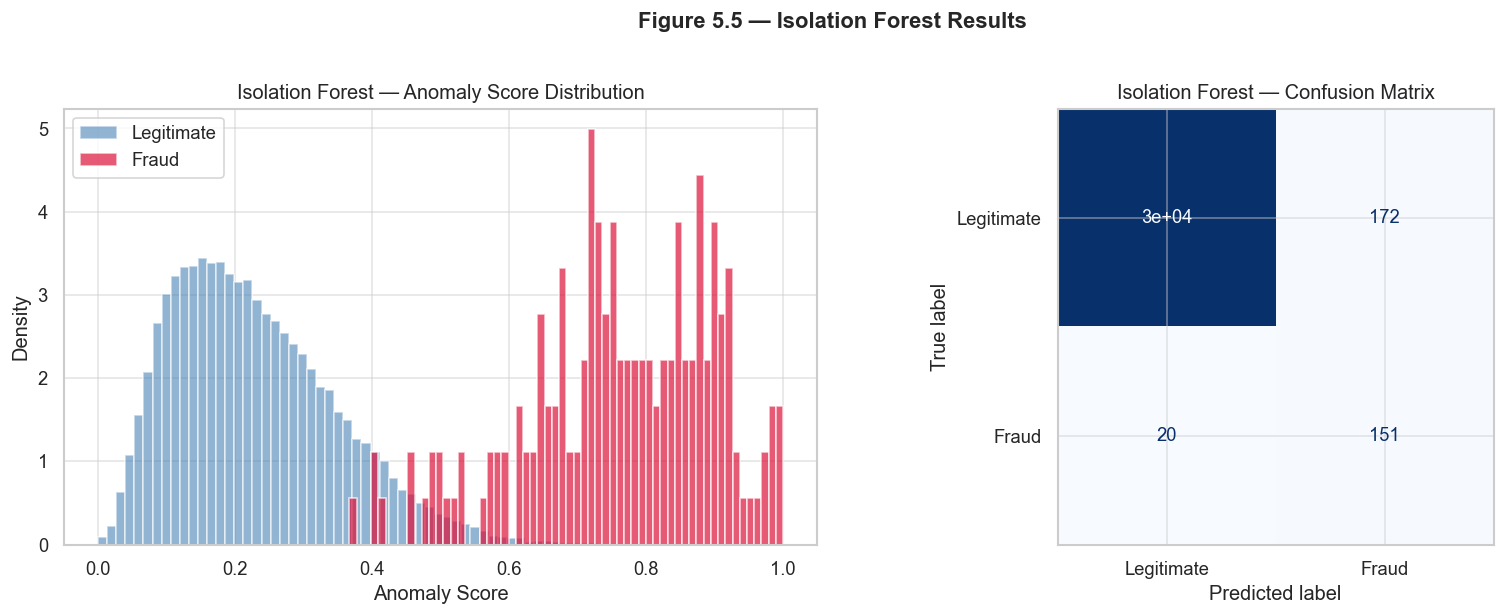

Saved: data/fig5_5_isolation_forest.png


In [5]:
# Isolation Forest anomaly score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution by class
axes[0].hist(iso_scores[y_test==0], bins=60, alpha=0.6,
             color='steelblue', label='Legitimate', density=True)
axes[0].hist(iso_scores[y_test==1], bins=60, alpha=0.7,
             color='crimson', label='Fraud', density=True)
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Isolation Forest — Anomaly Score Distribution')
axes[0].legend()

# Confusion matrix
cm = confusion_matrix(y_test, iso_preds)
ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraud']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Isolation Forest — Confusion Matrix')

plt.suptitle('Figure 5.5 — Isolation Forest Results', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/fig5_5_isolation_forest.png', bbox_inches='tight')
plt.show()
print('Saved: data/fig5_5_isolation_forest.png')

---
## Section 5 — LSTM Autoencoder

### How It Works (Plain Language)
An Autoencoder is a neural network trained to compress data and then reconstruct it.
It is trained only on legitimate transactions — so it learns to reconstruct normal behaviour well.
When it sees a fraudulent transaction, it cannot reconstruct it accurately
because it has never learned that pattern.
The reconstruction error becomes the anomaly score — high error = likely fraud.

The LSTM layer makes it sensitive to **sequential patterns** — not just individual
transaction values, but how a user's behaviour changes over time.

In [6]:
# Reshape data for LSTM — requires 3D input: (samples, timesteps, features)
# We treat each transaction as a sequence of length 1
# This is a valid approach when per-transaction features already encode temporal context
# (velocity_1h, velocity_6h, velocity_24h capture the sequential history)

TIMESTEPS = 1
N_FEATURES = X_train_scaled.shape[1]

X_train_lstm       = X_train_scaled.reshape(-1, TIMESTEPS, N_FEATURES)
X_train_legit_lstm = X_train_legit.reshape(-1, TIMESTEPS, N_FEATURES)
X_val_lstm         = X_val_scaled.reshape(-1, TIMESTEPS, N_FEATURES)
X_test_lstm        = X_test_scaled.reshape(-1, TIMESTEPS, N_FEATURES)

print(f'LSTM input shape (train legit) : {X_train_legit_lstm.shape}')
print(f'LSTM input shape (test)        : {X_test_lstm.shape}')

LSTM input shape (train legit) : (139324, 1, 22)
LSTM input shape (test)        : (30000, 1, 22)


In [7]:
def build_lstm_autoencoder(timesteps, n_features):
    """
    LSTM Autoencoder architecture:
    Encoder: compresses the transaction into a latent representation
    Decoder: reconstructs the transaction from the latent representation
    Loss:    mean squared error between input and reconstruction
    """
    inputs = Input(shape=(timesteps, n_features))

    # Encoder
    x = LSTM(64, activation='tanh', return_sequences=True)(inputs)
    x = Dropout(0.2)(x)
    x = LSTM(32, activation='tanh', return_sequences=False)(x)
    encoded = Dense(16, activation='relu')(x)   # latent space

    # Decoder
    x = RepeatVector(timesteps)(encoded)
    x = LSTM(32, activation='tanh', return_sequences=True)(x)
    x = Dropout(0.2)(x)
    x = LSTM(64, activation='tanh', return_sequences=True)(x)
    outputs = TimeDistributed(Dense(n_features))(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

lstm_ae = build_lstm_autoencoder(TIMESTEPS, N_FEATURES)
lstm_ae.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1, 22)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 1, 64)          │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 1, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 1, 32)          │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 1, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 1, 22)          │         1,430 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,750 (264.65 KB)

 Trainable params: 67,750 (264.65 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
print('Training LSTM Autoencoder on legitimate transactions only...')
print('This takes 3-8 minutes depending on your machine.\n')

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

history = lstm_ae.fit(
    X_train_legit_lstm, X_train_legit_lstm,   # input = target (reconstruction)
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

print('\nTraining complete.')

Training LSTM Autoencoder on legitimate transactions only...
This takes 3-8 minutes depending on your machine.

Epoch 1/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - loss: 0.5624 - val_loss: 0.3361 - learning_rate: 0.0010
Epoch 2/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 37s 38ms/step - loss: 0.2848 - val_loss: 0.1585 - learning_rate: 0.0010
Epoch 3/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.1991 - val_loss: 0.1189 - learning_rate: 0.0010
Epoch 4/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.1612 - val_loss: 0.0813 - learning_rate: 0.0010
Epoch 5/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 0.1393 - val_loss: 0.0716 - learning_rate: 0.0010
Epoch 6/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 31s 41ms/step - loss: 0.1279 - val_loss: 0.0622 - learning_rate: 0.0010
Epoch 7/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.1136 - val_loss: 0.0481 - learning_rate: 0.0010
Epoch 8/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1035 - val_loss: 0.0443 - learning_rate: 0

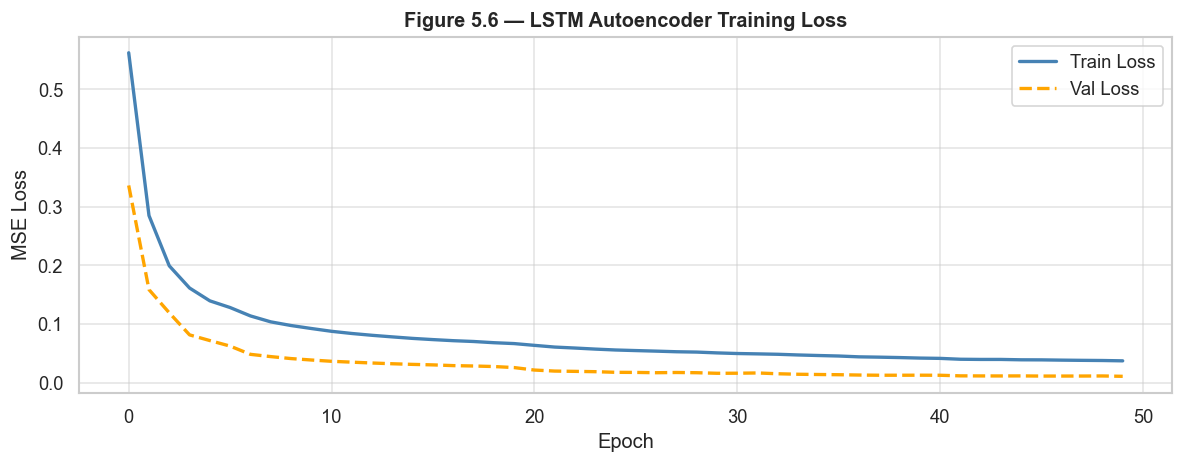

Saved: data/fig5_6_lstm_training_loss.png


In [9]:
# Training loss curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     label='Train Loss', color='steelblue', linewidth=2)
ax.plot(history.history['val_loss'], label='Val Loss',   color='orange',    linewidth=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Figure 5.6 — LSTM Autoencoder Training Loss', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('data/fig5_6_lstm_training_loss.png', bbox_inches='tight')
plt.show()
print('Saved: data/fig5_6_lstm_training_loss.png')

---
## Section 6 — LSTM Reconstruction Error & Threshold

In [10]:
# Compute reconstruction error on test set
X_test_reconstructed = lstm_ae.predict(X_test_lstm, verbose=0)

# Mean squared error per transaction
lstm_errors = np.mean(
    np.power(X_test_lstm - X_test_reconstructed, 2),
    axis=(1, 2)
)

# Normalise to 0-1 anomaly score
lstm_scores = (lstm_errors - lstm_errors.min()) / \
              (lstm_errors.max() - lstm_errors.min())

print(f'Reconstruction error — Legitimate: mean={lstm_errors[y_test==0].mean():.4f}')
print(f'Reconstruction error — Fraud:      mean={lstm_errors[y_test==1].mean():.4f}')
print()
print('A higher reconstruction error for fraud confirms the autoencoder')
print('learned normal behaviour and struggles with anomalous patterns.')

Reconstruction error — Legitimate: mean=0.0119
Reconstruction error — Fraud:      mean=25.1576

A higher reconstruction error for fraud confirms the autoencoder
learned normal behaviour and struggles with anomalous patterns.


In [11]:
# Find optimal threshold on validation set
X_val_reconstructed = lstm_ae.predict(X_val_lstm, verbose=0)
val_errors = np.mean(np.power(X_val_lstm - X_val_reconstructed, 2), axis=(1,2))
val_scores = (val_errors - val_errors.min()) / (val_errors.max() - val_errors.min())

thresholds = np.arange(0.01, 0.99, 0.01)
f1_scores  = [f1_score(y_val, (val_scores >= t).astype(int), zero_division=0)
              for t in thresholds]

best_idx        = np.argmax(f1_scores)
LSTM_THRESHOLD  = thresholds[best_idx]
lstm_preds      = (lstm_scores >= LSTM_THRESHOLD).astype(int)

lstm_precision = precision_score(y_test, lstm_preds, zero_division=0)
lstm_recall    = recall_score(y_test, lstm_preds, zero_division=0)
lstm_f1        = f1_score(y_test, lstm_preds, zero_division=0)
lstm_roc_auc   = roc_auc_score(y_test, lstm_scores)
lstm_pr_auc    = average_precision_score(y_test, lstm_scores)

print('LSTM AUTOENCODER — TEST RESULTS')
print('='*45)
print(f'Threshold : {LSTM_THRESHOLD:.2f}')
print(f'Precision : {lstm_precision:.4f}')
print(f'Recall    : {lstm_recall:.4f}')
print(f'F1 Score  : {lstm_f1:.4f}')
print(f'ROC-AUC   : {lstm_roc_auc:.4f}')
print(f'PR-AUC    : {lstm_pr_auc:.4f}')

LSTM AUTOENCODER — TEST RESULTS
Threshold : 0.01
Precision : 1.0000
Recall    : 0.6842
F1 Score  : 0.8125
ROC-AUC   : 0.9968
PR-AUC    : 0.9248


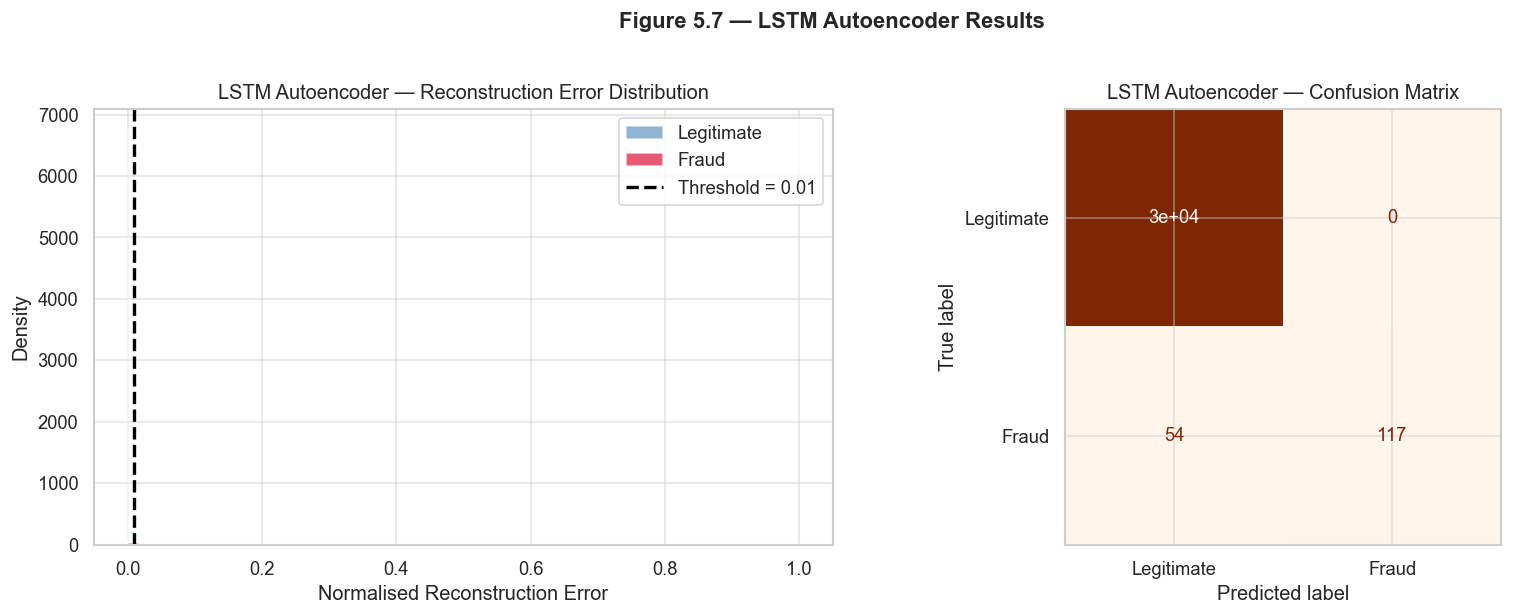

In [12]:
# Reconstruction error distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(lstm_scores[y_test==0], bins=60, alpha=0.6,
             color='steelblue', label='Legitimate', density=True)
axes[0].hist(lstm_scores[y_test==1], bins=60, alpha=0.7,
             color='crimson', label='Fraud', density=True)
axes[0].axvline(x=LSTM_THRESHOLD, color='black', linestyle='--',
                linewidth=2, label=f'Threshold = {LSTM_THRESHOLD:.2f}')
axes[0].set_xlabel('Normalised Reconstruction Error')
axes[0].set_ylabel('Density')
axes[0].set_title('LSTM Autoencoder — Reconstruction Error Distribution')
axes[0].legend()

cm = confusion_matrix(y_test, lstm_preds)
ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraud']).plot(
    ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('LSTM Autoencoder — Confusion Matrix')

plt.suptitle('Figure 5.7 — LSTM Autoencoder Results', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/fig5_7_lstm_autoencoder.png', bbox_inches='tight')
plt.show()

---
## Section 7 — Layer 2 Comparison

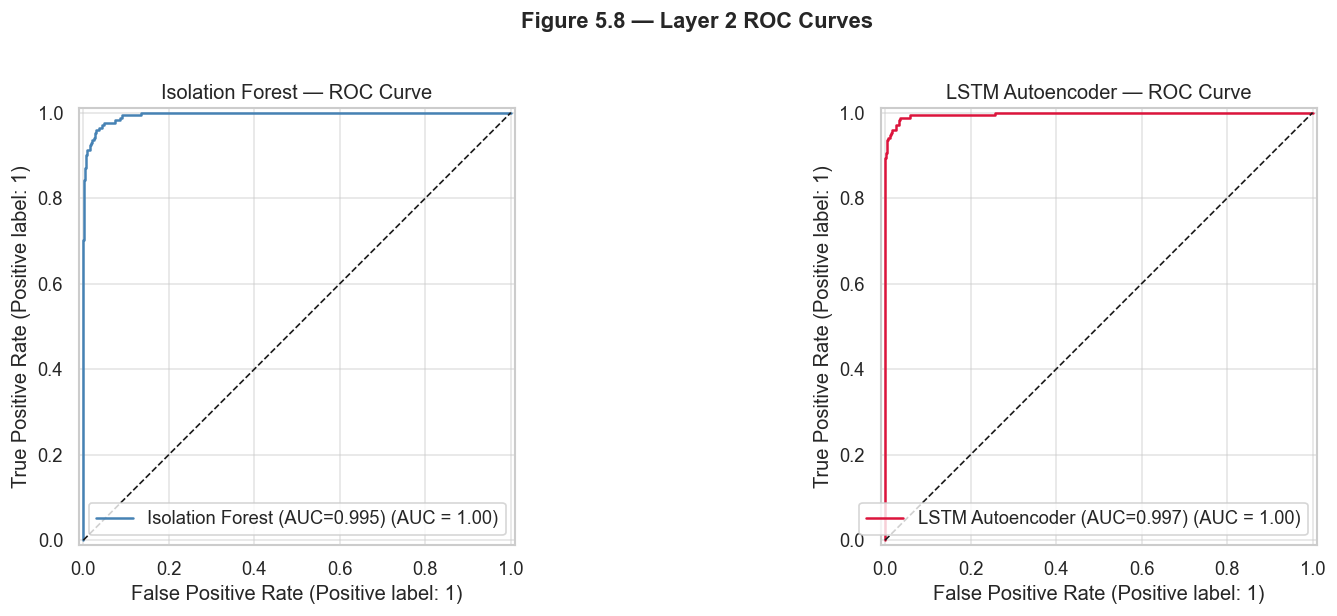

In [13]:
# ROC curves — both models side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(
    y_test, iso_scores, ax=axes[0],
    name=f'Isolation Forest (AUC={iso_roc_auc:.3f})',
    color='steelblue'
)
axes[0].plot([0,1],[0,1],'k--', linewidth=1)
axes[0].set_title('Isolation Forest — ROC Curve')

RocCurveDisplay.from_predictions(
    y_test, lstm_scores, ax=axes[1],
    name=f'LSTM Autoencoder (AUC={lstm_roc_auc:.3f})',
    color='crimson'
)
axes[1].plot([0,1],[0,1],'k--', linewidth=1)
axes[1].set_title('LSTM Autoencoder — ROC Curve')

plt.suptitle('Figure 5.8 — Layer 2 ROC Curves', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/fig5_8_layer2_roc.png', bbox_inches='tight')
plt.show()

In [14]:
# Full comparison table
print('='*65)
print('LAYER 2 COMPLETE — FULL COMPARISON TABLE')
print('='*65)
print(f'{"Model":<25} {"Precision":>10} {"Recall":>10} {"F1":>10} {"ROC-AUC":>10}')
print('-'*65)
print(f'{"Rule-Based Baseline":<25} {0.0154:>10.4f} {0.8100:>10.4f} {0.0302:>10.4f} {"N/A":>10}')
print(f'{"XGBoost (Layer 1)":<25} {0.9756:>10.4f} {0.9357:>10.4f} {0.9552:>10.4f} {0.9995:>10.4f}')
print(f'{"Isolation Forest (L2)":<25} {iso_precision:>10.4f} {iso_recall:>10.4f} {iso_f1:>10.4f} {iso_roc_auc:>10.4f}')
print(f'{"LSTM Autoencoder (L2)":<25} {lstm_precision:>10.4f} {lstm_recall:>10.4f} {lstm_f1:>10.4f} {lstm_roc_auc:>10.4f}')
print('='*65)
print()
print('Thesis note: Layer 2 models are not expected to match Layer 1 F1.')
print('Their role is to catch fraud that has NO label — novel attack patterns.')
print('Their scores feed into the ensemble as complementary signals, not replacements.')

LAYER 2 COMPLETE — FULL COMPARISON TABLE
Model                      Precision     Recall         F1    ROC-AUC
-----------------------------------------------------------------
Rule-Based Baseline           0.0154     0.8100     0.0302        N/A
XGBoost (Layer 1)             0.9756     0.9357     0.9552     0.9995
Isolation Forest (L2)         0.4675     0.8830     0.6113     0.9953
LSTM Autoencoder (L2)         1.0000     0.6842     0.8125     0.9968

Thesis note: Layer 2 models are not expected to match Layer 1 F1.
Their role is to catch fraud that has NO label — novel attack patterns.
Their scores feed into the ensemble as complementary signals, not replacements.


---
## Section 8 — Unique Fraud Caught by Layer 2
This is the key analytical result — fraud that Layer 1 missed but Layer 2 caught.

In [15]:
# Load Layer 1 predictions
import pickle
with open('models/xgboost_layer1.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

from sklearn.preprocessing import LabelEncoder as LE

# Get Layer 1 predictions on test set
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = (xgb_probs >= 0.5).astype(int)

# Fraud caught by each model
fraud_idx        = np.where(y_test == 1)[0]
caught_xgb       = set(fraud_idx[xgb_preds[fraud_idx] == 1])
caught_iso       = set(fraud_idx[iso_preds[fraud_idx] == 1])
caught_lstm      = set(fraud_idx[lstm_preds[fraud_idx] == 1])

only_xgb         = caught_xgb - caught_iso - caught_lstm
only_iso         = caught_iso - caught_xgb - caught_lstm
only_lstm        = caught_lstm - caught_xgb - caught_iso
caught_by_l2_not_l1 = (caught_iso | caught_lstm) - caught_xgb

print('FRAUD DETECTION COVERAGE ANALYSIS')
print('='*50)
print(f'Total fraud in test set          : {len(fraud_idx)}')
print(f'Caught by XGBoost only           : {len(only_xgb)}')
print(f'Caught by Isolation Forest only  : {len(only_iso)}')
print(f'Caught by LSTM only              : {len(only_lstm)}')
print(f'Caught by Layer 2 but NOT Layer 1: {len(caught_by_l2_not_l1)}')
print()
print('Thesis note: The cases caught by Layer 2 but not Layer 1')
print('represent novel fraud patterns that supervised learning missed.')
print('This is the empirical justification for the hybrid architecture.')

FRAUD DETECTION COVERAGE ANALYSIS
Total fraud in test set          : 171
Caught by XGBoost only           : 8
Caught by Isolation Forest only  : 3
Caught by LSTM only              : 0
Caught by Layer 2 but NOT Layer 1: 3

Thesis note: The cases caught by Layer 2 but not Layer 1
represent novel fraud patterns that supervised learning missed.
This is the empirical justification for the hybrid architecture.


---
## Section 9 — Save Models & Scores

In [16]:
# Save Isolation Forest
with open('models/isolation_forest.pkl', 'wb') as f:
    pickle.dump(iso_forest, f)

# Save scaler
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save LSTM Autoencoder
lstm_ae.save('models/lstm_autoencoder.keras')

# Save anomaly scores for ensemble use in Layer 3
np.save('models/iso_scores_test.npy',  iso_scores)
np.save('models/lstm_scores_test.npy', lstm_scores)
np.save('models/xgb_scores_test.npy',  xgb_probs)

# Save results
results = {
    'isolation_forest': {
        'precision': float(round(iso_precision, 4)),
        'recall'   : float(round(iso_recall, 4)),
        'f1'       : float(round(iso_f1, 4)),
        'roc_auc'  : float(round(iso_roc_auc, 4)),
        'pr_auc'   : float(round(iso_pr_auc, 4)),
    },
    'lstm_autoencoder': {
        'threshold': float(LSTM_THRESHOLD),
        'precision': float(round(lstm_precision, 4)),
        'recall'   : float(round(lstm_recall, 4)),
        'f1'       : float(round(lstm_f1, 4)),
        'roc_auc'  : float(round(lstm_roc_auc, 4)),
        'pr_auc'   : float(round(lstm_pr_auc, 4)),
    },
    'fraud_caught_by_l2_not_l1': len(caught_by_l2_not_l1)
}

with open('models/layer2_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Models saved:')
print('  models/isolation_forest.pkl')
print('  models/scaler.pkl')
print('  models/lstm_autoencoder.keras')
print('  models/iso_scores_test.npy')
print('  models/lstm_scores_test.npy')
print('  models/xgb_scores_test.npy')
print('  models/layer2_results.json')
print()
print(json.dumps(results, indent=2))

Models saved:
  models/isolation_forest.pkl
  models/scaler.pkl
  models/lstm_autoencoder.keras
  models/iso_scores_test.npy
  models/lstm_scores_test.npy
  models/xgb_scores_test.npy
  models/layer2_results.json

{
  "isolation_forest": {
    "precision": 0.4675,
    "recall": 0.883,
    "f1": 0.6113,
    "roc_auc": 0.9953,
    "pr_auc": 0.8416
  },
  "lstm_autoencoder": {
    "threshold": 0.01,
    "precision": 1.0,
    "recall": 0.6842,
    "f1": 0.8125,
    "roc_auc": 0.9968,
    "pr_auc": 0.9248
  },
  "fraud_caught_by_l2_not_l1": 3
}


---
## Section 10 — Layer 2 Summary

In [17]:
print('='*60)
print('LAYER 2 COMPLETE — UNSUPERVISED ANOMALY DETECTION')
print('='*60)
print(f"""
Models trained:
  1. Isolation Forest  — point anomaly detection
  2. LSTM Autoencoder  — sequential reconstruction error

Key finding:
  Layer 2 caught {len(caught_by_l2_not_l1)} fraud cases that XGBoost (Layer 1) missed.
  This validates the hybrid architecture — no single model is sufficient.

Figures saved:
  fig5_5_isolation_forest.png
  fig5_6_lstm_training_loss.png
  fig5_7_lstm_autoencoder.png
  fig5_8_layer2_roc.png

Next step: model_layer3_graph.ipynb
  — NetworkX agent network graph construction
  — Louvain community detection for fraud ring identification
  — Graph-based risk scores for coordinated agent fraud
""")

LAYER 2 COMPLETE — UNSUPERVISED ANOMALY DETECTION

Models trained:
  1. Isolation Forest  — point anomaly detection
  2. LSTM Autoencoder  — sequential reconstruction error

Key finding:
  Layer 2 caught 3 fraud cases that XGBoost (Layer 1) missed.
  This validates the hybrid architecture — no single model is sufficient.

Figures saved:
  fig5_5_isolation_forest.png
  fig5_6_lstm_training_loss.png
  fig5_7_lstm_autoencoder.png
  fig5_8_layer2_roc.png

Next step: model_layer3_graph.ipynb
  — NetworkX agent network graph construction
  — Louvain community detection for fraud ring identification
  — Graph-based risk scores for coordinated agent fraud

